# "Collaborative Filtering With-Cross-Entropy-Loss"
> Using Fastai to for Collaborative Filtering on the Movie Lens dataset using cross-entropy loss.

- toc: true
- badges: true
- comments: true
- use_math: true    
- categories: [fastai, jupyter]

# Introduction
We work through a problem posed in Chapter 8 of {% cite fastbook2020 %}.

In [1]:
from fastai.collab import *
from fastai.tabular.all import *
path = untar_data(URLs.ML_100k)

In [2]:
Path.BASE_PATH = path
path.ls()

(#23) [Path('allbut.pl'),Path('mku.sh'),Path('README'),Path('u.data'),Path('u.genre'),Path('u.info'),Path('u.item'),Path('u.occupation'),Path('u.user'),Path('u1.base')...]

In [3]:
ratings = pd.read_csv(path/'u.data', delimiter='\t', header=None,
                     names=['user','movie','rating','timestamp'])
ratings.head()

,user,movie,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


We see that the rating can be one of the following values:

In [4]:
ratings.rating.unique()

array([3, 1, 2, 4, 5])

In [5]:
movies = pd.read_csv(path/'u.item', delimiter='|', encoding='latin-1',
                     usecols=(0,1), names=('movie','title'), header=None)
movies.head()

,movie,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [6]:
ratings = ratings.merge(movies)
ratings.head()

,user,movie,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,63,242,3,875747190,Kolya (1996)
2,226,242,5,883888671,Kolya (1996)
3,154,242,3,879138235,Kolya (1996)
4,306,242,5,876503793,Kolya (1996)


# DataLoaders

In [7]:
dls = CollabDataLoaders.from_df(ratings, item_name='title', bs=64)
dls.show_batch()

,user,title,rating
0,795,Highlander (1986),4
1,315,Boogie Nights (1997),4
2,805,Henry V (1989),5
3,303,Austin Powers: International Man of Mystery (1997),4
4,192,Star Wars (1977),4
5,632,Aliens (1986),3
6,406,Six Degrees of Separation (1993),4
7,556,To Kill a Mockingbird (1962),5
8,882,Mars Attacks! (1996),3
9,365,Primal Fear (1996),4


# Probabilistic Matrix Factorization baseline

Underneath the covers we have a dot product model (where the dot product is between an embedding of the user and the item). We use L2 regularization (wd=0.5) and use y_range to make sure the sigmoid_range can get to a rating of $5$. Recall that in the sigmoid function only an activation of $\infty$ will get us a $1$. This will use the MSE as the loss function.

In [8]:
learn = collab_learner(dls, n_factors=50, y_range=(0,5.5))
learn.fit_one_cycle(5, 5e-3, wd=0.1)

epoch,train_loss,valid_loss,time
0,0.927197,0.965499,00:07
1,0.862236,0.884941,00:07
2,0.735082,0.845000,00:07
3,0.610900,0.831931,00:07
4,0.476653,0.831607,00:07


So $0.831$ is what we want to beat!

# Deep Learning baseline
Instead of a Dot Product model we use a model where the user and the movie embeddings are concatenated together and then passed through a neural net. We continue to use MSE as our loss.

In [9]:
learn2 = collab_learner(dls, n_factors=50, use_nn=True, layers=[100], y_range=(0,5.5))
learn2.fit_one_cycle(5, 5e-3, wd=0.1)

epoch,train_loss,valid_loss,time
0,1.005202,0.983641,00:08
1,0.918563,0.921814,00:08
2,0.869899,0.877524,00:08
3,0.789815,0.858055,00:08
4,0.756436,0.859034,00:08


The model is as follows:

In [10]:
learn2.model

EmbeddingNN(
  (embeds): ModuleList(
    (0): Embedding(944, 74)
    (1): Embedding(1665, 102)
  )
  (emb_drop): Dropout(p=0.0, inplace=False)
  (bn_cont): BatchNorm1d(0, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): Sequential(
    (0): LinBnDrop(
      (0): Linear(in_features=176, out_features=100, bias=False)
      (1): ReLU(inplace=True)
      (2): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): LinBnDrop(
      (0): Linear(in_features=100, out_features=1, bias=True)
    )
    (2): SigmoidRange(low=0, high=5.5)
  )
)

# Cross Entropy Loss
Turn each rating into a class label by subtracting one. Recall we saw that ratings are integers from $1$ to $5$.

In [11]:
ratings['class'] = ratings['rating'] - 1
ratings.head(n=5)

,user,movie,rating,timestamp,title,class
0,196,242,3,881250949,Kolya (1996),2
1,63,242,3,875747190,Kolya (1996),2
2,226,242,5,883888671,Kolya (1996),4
3,154,242,3,879138235,Kolya (1996),2
4,306,242,5,876503793,Kolya (1996),4


In [12]:
ratings['class'].unique()

array([2, 4, 3, 1, 0])

In [13]:
dls3 = CollabDataLoaders.from_df(ratings, item_name='title', rating_name='class', bs=64)
dls3.show_batch()

,user,title,class
0,593,"Clockwork Orange, A (1971)",4
1,887,"Haunted World of Edward D. Wood Jr., The (1995)",4
2,89,Welcome to the Dollhouse (1995),1
3,438,"River Wild, The (1994)",3
4,327,Reservoir Dogs (1992),3
5,320,Virtuosity (1995),3
6,101,Phenomenon (1996),3
7,184,Raising Arizona (1987),3
8,546,Psycho (1960),3
9,20,Miracle on 34th Street (1994),2


Create a class that is able to output as many activations as there are classes.

In [14]:
class CollabNN(Module):
    def __init__(self, user_sz, item_sz, n_act=100, n_classes=5):
        self.user_factors = Embedding(*user_sz)
        self.item_factors = Embedding(*item_sz)
        self.layers = nn.Sequential(
            nn.Linear(user_sz[1]+item_sz[1], n_act),
            nn.ReLU(),
            nn.Linear(n_act, n_classes))
        
    def forward(self, x):
        embs = self.user_factors(x[:,0]),self.item_factors(x[:,1])
        return self.layers(torch.cat(embs, dim=1))

In [15]:
embs = get_emb_sz(dls3)
embs

[(944, 74), (1665, 102)]

In [16]:
model = CollabNN(*embs)

Examine a batch of inputs and outputs

In [17]:
x, y = dls3.one_batch()
x[:3], y[:3]

(tensor([[ 942,  230],
         [ 102, 1050],
         [ 392,  905]]),
 tensor([[4],
         [1],
         [1]], dtype=torch.int8))

Get activations by passing through the model

In [18]:
model(x[:3])

tensor([[-0.0130, -0.0674, -0.0230, -0.0280, -0.0931],
        [-0.0097, -0.0647, -0.0267, -0.0313, -0.0911],
        [-0.0108, -0.0649, -0.0259, -0.0275, -0.0948]],
       grad_fn=<AddmmBackward>)

Apply softmax to the activations

In [19]:
torch.softmax(model(x[:3]), dim=-1)

tensor([[0.2064, 0.1955, 0.2043, 0.2033, 0.1905],
        [0.2070, 0.1960, 0.2035, 0.2026, 0.1909],
        [0.2068, 0.1959, 0.2037, 0.2034, 0.1902]], grad_fn=<SoftmaxBackward>)

Take the argmax to get the prediction of the class

In [20]:
torch.softmax(model(x[:3]), dim=-1).argmax(dim=-1)

tensor([0, 0, 0])

Unsqueeze to match the shape of the y's

In [21]:
torch.softmax(model(x[:3]), dim=-1).argmax(dim=-1).unsqueeze(-1)

tensor([[0],
        [0],
        [0]])

Convert to float and compute the mse_loss

In [22]:
F.mse_loss(torch.softmax(model(x[:3]), dim=-1).argmax(dim=-1).unsqueeze(-1).float(), y[:3])

tensor(6.)

Create our custom mse function that can get a loss from these activations for the different classes. We do this so we can compare the validation loss metric against the previous baselines. Clearly cross entropy loss cannot be compared directly to the mean squared error.

In [23]:
def ks_mse(inp, targ, axis=-1):
    sm_acts = torch.softmax(inp, dim=-1)
    preds = sm_acts.argmax(dim=axis).unsqueeze(-1)
    return F.mse_loss(preds.float(), targ).mean()

Compare with our custom function

In [24]:
ks_mse(model(x[:3]), y[:3])

tensor(6.)

In [25]:
learn3 = Learner(dls3, model, loss_func=CrossEntropyLossFlat(), metrics=[accuracy, ks_mse])

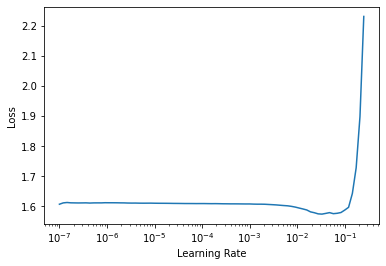

In [26]:
lrs = learn3.lr_find()

In [27]:
lrs

SuggestedLRs(lr_min=0.0033113110810518267, lr_steep=0.015848932787775993)

In [29]:
learn3.fit_one_cycle(5, 4e-3, wd=0.01)

epoch,train_loss,valid_loss,accuracy,ks_mse,time
0,1.103988,1.303491,0.436350,1.162650,00:08
1,1.122083,1.293717,0.440350,1.138250,00:08
2,1.071902,1.308509,0.434700,1.214100,00:08
3,0.990249,1.351775,0.431450,1.208450,00:08
4,0.925784,1.375744,0.431400,1.225100,00:08


Unfortunately we come up short and cannot beat our baseline.

# References
{% bibliography --cited %}